In [1]:
import sys
sys.path.insert(0, "Python_Pipeline")

In [2]:
import json, subprocess
from layer2 import load_products, load_financial, config_versions
from layer3 import from_answers, run_model, ScenarioParams

In [3]:
result = subprocess.run(
    ["python3", "read_questionnaire_input.py",
     "--input", "data/chengdu_jinniu_2026_filled.xlsx",
     "--answers-only", "--compact"],
    capture_output=True, text=True
)
answers = json.loads(result.stdout)
answers

{'INT1': 'CD-JN-2026-LD-01',
 'INT2': 'China, Sichuan Province, Chengdu City',
 'INT3': 'Li Mingzhi, Regional Sales Manager',
 'INT4': 'li.mingzhi@hpwinner.com',
 'INT5': '2026-05-11',
 'INT6': 'CNY',
 'INT7': 'Qualified',
 'INT8': '2026-08-30',
 'A1': 'Municipal',
 'A2': 'Chengdu City Urban Lighting Management Bureau',
 'A3': 'Jinniu District and Qingbaijiang District — arterial and secondary roads, 42 km total',
 'A4': 'Retrofit',
 'A5': 3200,
 'A6': 11500,
 'A7': 'HPS',
 'A8': 14,
 'A9': 7.5,
 'B1': 2300000,
 'B2': 870000,
 'B3': 1150000,
 'B4': 'No',
 'B5': 'Rising',
 'C1': 250,
 'C2': 80,
 'C3': 10.5,
 'C4': 3833,
 'C5': 'Time-of-use (TOU)',
 'C6': 0.75,
 'D1': 420000,
 'D2': 10,
 'D3': 3,
 'D4': 2,
 'D5': 360,
 'E1': 'Yes',
 'E2': 8500,
 'E3': 650000,
 'E4': 3800,
 'E5': 'Yes',
 'F1': '4G/5G',
 'F2': 'Shared',
 'F3': 'No',
 'F4': 'Medium',
 'G1': 'No',
 'G2': '6 years',
 'G3': 'Yes',
 'G4': 'Fixed escalator (% per year)',
 'G5': 'Annual',
 'H1': 10,
 'H2': 'No',
 'H3': 'Accept',


In [4]:
deal    = from_answers(answers)
product = load_products().get("ai_road_lamp")
params  = ScenarioParams.from_defaults("ai_road_lamp", product, load_financial(), deal)

params.annual_service_fee_per_light = 600

r = run_model(deal, product, params, config_versions())
print(r.npv, r.irr, r.payback_years, r.go_nogo)

1343095.0399715551 0.10269747697156895 6.451549777210064 go


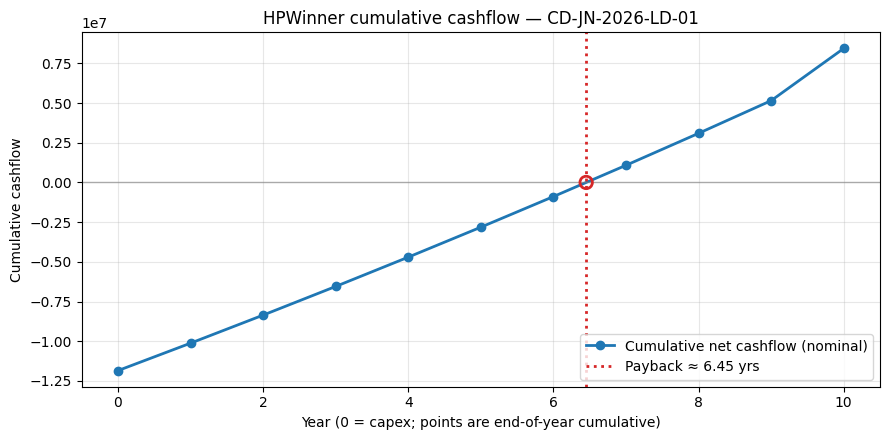

In [5]:
import matplotlib.pyplot as plt

# Uses `r` from run_model(...) above — change name if yours differs
rows = r.yearly_cashflows
years = [row.year for row in rows]
cum = [row.cumulative_cashflow for row in rows]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(years, cum, "o-", lw=2, ms=6, label="Cumulative net cashflow (nominal)")
ax.axhline(0, color="gray", lw=1, ls="-", alpha=0.6)

pb = r.payback_years
if pb is not None:
    ax.axvline(pb, color="C3", ls=":", lw=2, label=f"Payback ≈ {pb:.2f} yrs")
    # Mark zero crossing on the curve (optional)
    ax.scatter([pb], [0], s=80, zorder=5, facecolors="none", edgecolors="C3", lw=2)
else:
    ax.text(0.02, 0.98, "No payback within model horizon", transform=ax.transAxes, va="top")

ax.set_xlabel("Year (0 = capex; points are end-of-year cumulative)")
ax.set_ylabel("Cumulative cashflow")
ax.set_title(f"HPWinner cumulative cashflow — {r.deal_id}")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

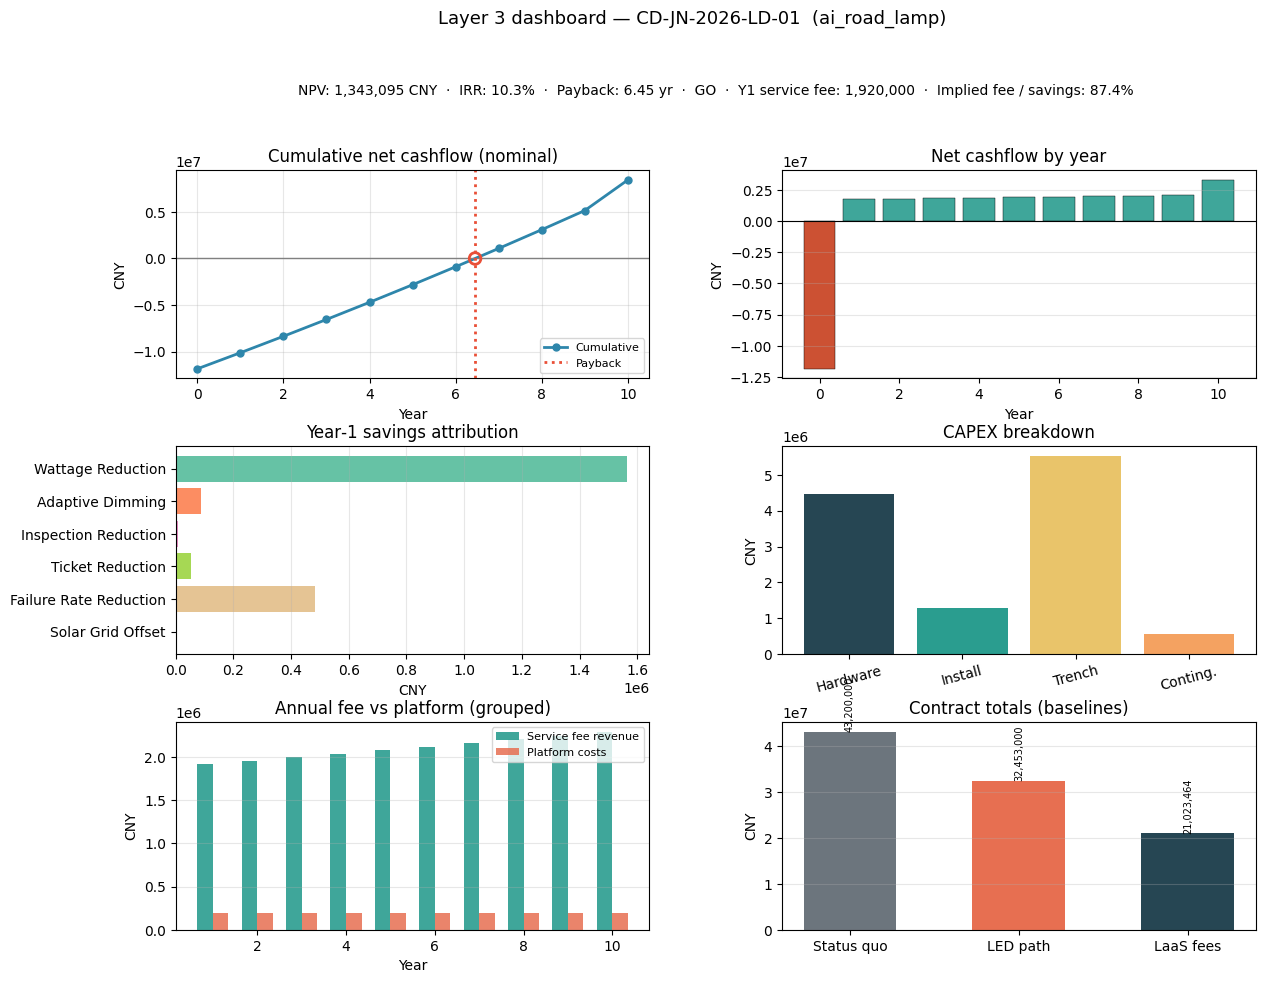

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def plot_layer3_dashboard(r, currency: str = "CNY"):
    """Mirror-style panels for Layer 3 outputs (KPI strip + cashflow + savings + CAPEX + baselines)."""
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(
        4, 2,
        height_ratios=[0.11, 1.0, 1.0, 1.0],
        hspace=0.42,
        wspace=0.28,
        left=0.07,
        right=0.97,
        top=0.91,
        bottom=0.06,
    )

    # --- KPI strip ---
    axk = fig.add_subplot(gs[0, :])
    axk.axis("off")
    irr = r.irr
    irr_s = f"{100 * irr:.1f}%" if irr is not None and irr == irr else "—"
    pb = r.payback_years
    pb_s = f"{pb:.2f} yr" if pb is not None else "—"
    impl = r.hpwinner_implied_savings_share_pct
    impl_s = f"{impl:.1f}%" if impl is not None else "—"
    kpi = (
        f"NPV: {r.npv:,.0f} {currency}  ·  IRR: {irr_s}  ·  Payback: {pb_s}  ·  {r.go_nogo.upper()}  ·  "
        f"Y1 service fee: {r.annual_service_fee_y1:,.0f}  ·  Implied fee / savings: {impl_s}"
    )
    axk.text(0.5, 0.5, kpi, ha="center", va="center", fontsize=10, transform=axk.transAxes)

    rows = r.yearly_cashflows
    ye = [x.year for x in rows]

    # --- Cumulative CF + payback ---
    ax1 = fig.add_subplot(gs[1, 0])
    cu = [x.cumulative_cashflow for x in rows]
    ax1.plot(ye, cu, "o-", lw=2, ms=5, color="#2E86AB", label="Cumulative")
    ax1.axhline(0, color="gray", lw=1)
    if pb is not None:
        ax1.axvline(pb, color="#E94F37", ls=":", lw=2, label="Payback")
        ax1.scatter([pb], [0], s=70, zorder=5, facecolors="none", edgecolors="#E94F37", lw=2)
        ax1.legend(loc="lower right", fontsize=8)
    ax1.set_title("Cumulative net cashflow (nominal)")
    ax1.set_xlabel("Year"); ax1.set_ylabel(currency); ax1.grid(True, alpha=0.3)

    # --- Net CF by year ---
    ax2 = fig.add_subplot(gs[1, 1])
    nets = [x.net_cashflow for x in rows]
    colors = ["#C73E1D" if v < 0 else "#2A9D8F" for v in nets]
    ax2.bar(ye, nets, color=colors, edgecolor="black", linewidth=0.35, alpha=0.9)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_title("Net cashflow by year")
    ax2.set_xlabel("Year"); ax2.set_ylabel(currency); ax2.grid(True, axis="y", alpha=0.3)

    # --- Savings attribution (Y1) ---
    ax3 = fig.add_subplot(gs[2, 0])
    sd = r.annual_savings.as_dict()
    sd.pop("total", None)
    labs = [k.replace("_", " ").title() for k in sd.keys()]
    vals = list(sd.values())
    n = max(len(vals), 1)
    cols = plt.cm.Set2(np.linspace(0, 1, n))
    ax3.barh(labs, vals, color=cols)
    ax3.set_title("Year‑1 savings attribution")
    ax3.set_xlabel(currency); ax3.invert_yaxis(); ax3.grid(True, axis="x", alpha=0.3)

    # --- CAPEX breakdown ---
    ax4 = fig.add_subplot(gs[2, 1])
    cx = r.capex
    parts = [("Hardware", cx.hardware), ("Install", cx.installation), ("Trench", cx.trenching), ("Conting.", cx.contingency)]
    ax4.bar([p[0] for p in parts], [p[1] for p in parts], color=["#264653", "#2A9D8F", "#E9C46A", "#F4A261"])
    ax4.set_title("CAPEX breakdown")
    ax4.set_ylabel(currency); ax4.tick_params(axis="x", rotation=15)

    # --- Fee vs platform (operating years) ---
    ax5 = fig.add_subplot(gs[3, 0])
    op = [x for x in rows if x.year >= 1]
    xs = np.array([x.year for x in op], dtype=float)
    fees = [x.service_fee_revenue for x in op]
    plat = [x.platform_costs for x in op]
    w = 0.35
    ax5.bar(xs - w / 2, fees, width=w, label="Service fee revenue", color="#2A9D8F", alpha=0.9)
    ax5.bar(xs + w / 2, plat, width=w, label="Platform costs", color="#E76F51", alpha=0.85)
    ax5.set_title("Annual fee vs platform (grouped)")
    ax5.set_xlabel("Year"); ax5.set_ylabel(currency); ax5.legend(fontsize=8); ax5.grid(True, axis="y", alpha=0.3)

    # --- Contract-horizon totals ---
    ax6 = fig.add_subplot(gs[3, 1])
    b = r.baselines
    names = ["Status quo", "LED path", "LaaS fees"]
    vals = [b.status_quo_total, b.led_replacement_total, b.laas_customer_total]
    x = np.arange(len(names))
    bars = ax6.bar(x, vals, color=["#6C757D", "#E76F51", "#264653"], width=0.55)
    ax6.set_xticks(x, names, rotation=0)
    ax6.set_title("Contract totals (baselines)")
    ax6.set_ylabel(currency); ax6.grid(True, axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax6.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=7, rotation=90)

    fig.suptitle(f"Layer 3 dashboard — {r.deal_id}  ({r.product_key})", fontsize=13, y=0.98)
    return fig


ccy = getattr(deal, "currency", "CNY")
plot_layer3_dashboard(r, currency=ccy)
plt.show()

In [7]:
# Should match r.annual_savings.wattage_reduction exactly
manual = (deal.existing_wattage_W - deal.proposed_wattage_W) / 1000 \
         * deal.effective_annual_hours \
         * deal.n_lights \
         * deal.tariff_avg_per_kwh
print(manual, r.annual_savings.wattage_reduction)


1563864.0 1563864.0


In [8]:
import pandas as pd

rows = []
for fee in range(200, 1200, 50):
    params.annual_service_fee_per_light = fee
    r = run_model(deal, product, params, config_versions())
    rows.append({
        "fee_per_light": fee,
        "total_fee_yr":  r.annual_service_fee_y1,
        "customer_saving_yr": r.customer_net_saving_y1,
        "npv":     r.npv,
        "irr_pct": round(r.irr * 100, 1) if r.irr else None,
        "payback": round(r.payback_years, 1) if r.payback_years else None,
        "implied_share_pct": round(r.hpwinner_implied_savings_share_pct, 1),
        "verdict": r.go_nogo,
    })

df = pd.DataFrame(rows)
df

,fee_per_light,total_fee_yr,customer_saving_yr,npv,irr_pct,payback,implied_share_pct,verdict
0,200,640000,3680000.0,-7.944792e+06,-8.7,NaN,29.1,no-go
1,250,800000,3520000.0,-6.783806e+06,-5.7,NaN,36.4,no-go
2,300,960000,3360000.0,-5.622821e+06,-3.0,NaN,43.7,no-go
3,350,1120000,3200000.0,-4.461835e+06,-0.4,NaN,51.0,no-go
4,400,1280000,3040000.0,-3.300849e+06,1.9,9.4,58.3,no-go
5,450,1440000,2880000.0,-2.139863e+06,4.2,8.7,65.5,no-go
6,500,1600000,2720000.0,-9.788768e+05,6.3,7.8,72.8,no-go
7,550,1760000,2560000.0,1.821091e+05,8.3,7.1,80.1,go
8,600,1920000,2400000.0,1.343095e+06,10.3,6.5,87.4,go
9,650,2080000,2240000.0,2.504081e+06,12.2,5.9,94.7,go


In [9]:
results = {}
for pk in ["ai_road_lamp", "ai_battery_lamp", "ai_solar_lamp"]:
    prod = load_products().get(pk)
    p = ScenarioParams.from_defaults(pk, prod, load_financial(), deal)
    p.annual_service_fee_per_light = 600
    results[pk] = run_model(deal, prod, p, config_versions())

for pk, r in results.items():
    print(f"{pk:20}  CAPEX {r.capex.total:>10,.0f}  NPV {r.npv:>10,.0f}  IRR {r.irr*100:.1f}%  savings {r.annual_savings.total:>10,.0f}")

ai_road_lamp          CAPEX 11,849,250  NPV  1,343,095  IRR 10.3%  savings  2,197,126
ai_battery_lamp       CAPEX  8,064,000  NPV  5,210,682  IRR 20.0%  savings  2,197,126
ai_solar_lamp         CAPEX 10,752,000  NPV  2,647,188  IRR 12.8%  savings  2,682,844


In [10]:
base_params = ScenarioParams.from_defaults("ai_road_lamp", product, load_financial(), deal)
base_params.annual_service_fee_per_light = 600
base_npv = run_model(deal, product, base_params, config_versions()).npv

sliders = {
    "adaptive_dimming_pct":       (0, 25),
    "inspection_reduction_pct":   (0, 55),
    "ticket_reduction_pct":       (0, 50),
    "failure_reduction_pct":      (0, 80),
    "annual_fee_escalator_pct":   (0, 5),
    "hpwinner_wacc_pct":          (6, 12),
    "contingency_pct":            (0, 15),
}

for field, (lo, hi) in sliders.items():
    for val, label in [(lo, "low"), (hi, "high")]:
        p = base_params.model_copy()
        setattr(p, field, val)
        npv = run_model(deal, product, p, config_versions()).npv
        print(f"  {field} → {label} ({val}):  NPV {npv:,.0f}  delta {npv - base_npv:+,.0f}")

  adaptive_dimming_pct → low (0):  NPV 1,343,095  delta +0
  adaptive_dimming_pct → high (25):  NPV 1,343,095  delta +0
  inspection_reduction_pct → low (0):  NPV 1,343,095  delta +0
  inspection_reduction_pct → high (55):  NPV 1,343,095  delta +0
  ticket_reduction_pct → low (0):  NPV 1,343,095  delta +0
  ticket_reduction_pct → high (50):  NPV 1,343,095  delta +0
  failure_reduction_pct → low (0):  NPV 1,343,095  delta +0
  failure_reduction_pct → high (80):  NPV 1,343,095  delta +0
  annual_fee_escalator_pct → low (0):  NPV 294,620  delta -1,048,475
  annual_fee_escalator_pct → high (5):  NPV 3,123,687  delta +1,780,592
  hpwinner_wacc_pct → low (6):  NPV 2,726,624  delta +1,383,529
  hpwinner_wacc_pct → high (12):  NPV -888,263  delta -2,231,358
  contingency_pct → low (0):  NPV 1,881,209  delta +538,114
  contingency_pct → high (15):  NPV 266,866  delta -1,076,229


In [11]:
for cf in r.yearly_cashflows:
    bar = "█" * int(abs(cf.cumulative_cashflow) / 500000)
    sign = "+" if cf.cumulative_cashflow >= 0 else "-"
    print(f"Yr {cf.year:2d}  net {cf.net_cashflow:>10,.0f}  cumul {sign}{abs(cf.cumulative_cashflow):>10,.0f}  {bar}")

Yr  0  net -10,752,000  cumul -10,752,000  █████████████████████
Yr  1  net  1,766,400  cumul - 8,985,600  █████████████████
Yr  2  net  1,804,800  cumul - 7,180,800  ██████████████
Yr  3  net  1,843,968  cumul - 5,336,832  ██████████
Yr  4  net  1,883,919  cumul - 3,452,913  ██████
Yr  5  net  1,924,670  cumul - 1,528,243  ███
Yr  6  net  1,966,235  cumul +   437,992  
Yr  7  net  2,008,632  cumul + 2,446,624  ████
Yr  8  net  2,051,876  cumul + 4,498,501  ████████
Yr  9  net  2,095,986  cumul + 6,594,487  █████████████
Yr 10  net  3,216,178  cumul + 9,810,664  ███████████████████


In [12]:
# Fee above customer baseline — should warn
params.annual_service_fee_per_light = 2000
r_high = run_model(deal, product, params, config_versions())
print(r_high.warnings)
print(r_high.go_nogo)

# Fee = 0 — should warn and be no-go
params.annual_service_fee_per_light = 0
r_zero = run_model(deal, product, params, config_versions())
print(r_zero.warnings)

['Service fee (6,400,000) exceeds customer baseline (4,320,000) — customer has no incentive to sign.', 'Service fee (6,400,000) exceeds total modelled savings (2,197,126) — HPWinner would be charging more than the deal creates.']
borderline
['annual_service_fee_per_light is 0 — set it via the dashboard slider. Suggested floor: 312 CNY/light/yr']


In [13]:
from layer3 import from_answers

# Proposed wattage >= existing — should raise
bad = dict(answers)
bad["C2"] = 300  # higher than C1=250
try:
    from_answers(bad)
except ValueError as e:
    print(e)

# Missing required field
bad2 = dict(answers)
bad2["A5"] = None
try:
    from_answers(bad2)
except ValueError as e:
    print(e)

C2 proposed wattage (300.0W) must be less than C1 existing wattage (250.0W). Check that the questionnaire filled the right columns.
Missing or invalid required fields:
  • A5 (number of lights in scope) is required but missing


In [14]:
params.annual_service_fee_per_light = 600
r = run_model(deal, product, params, config_versions())

# Status quo should be exactly baseline × contract_yrs
expected_sq = deal.baseline_total_annual_cost * params.contract_yrs
print(f"Status quo check: {r.baselines.status_quo_total:,.0f} == {expected_sq:,.0f} → {abs(r.baselines.status_quo_total - expected_sq) < 1}")

# Customer should always save vs status quo at any reasonable fee
print(f"Customer saves vs SQ: {r.baselines.laas_customer_saving_vs_status_quo:,.0f}")
print(f"Customer saves vs LED: {r.baselines.laas_customer_saving_vs_led:,.0f}")

Status quo check: 43,200,000 == 43,200,000 → True
Customer saves vs SQ: 22,176,536
Customer saves vs LED: 11,429,536


In [15]:
import sys
sys.path.insert(0, "Python_Pipeline")

import json, subprocess
from layer2 import load_products, load_financial, load_savings, config_versions
from layer3 import from_answers, ScenarioParams
from layer4 import run_scenarios

# Load deal
raw = subprocess.run(
    ["python3", "read_questionnaire_input.py",
     "--input", "data/chengdu_jinniu_2026_filled.xlsx",
     "--answers-only", "--compact"],
    capture_output=True, text=True
)
answers = json.loads(raw.stdout)

# Build inputs
deal    = from_answers(answers)
product = load_products().get("ai_road_lamp")
params  = ScenarioParams.from_defaults("ai_road_lamp", product, load_financial(), deal)
params.annual_service_fee_per_light = 600

# Run all scenarios
results = run_scenarios(deal, product, params, load_savings(), load_financial(), config_versions(), mc_seed=42)

# Inspect
results.point_estimate.npv
results.tornado.rows
results.montecarlo.npv_range_label


'P10 598,330 / P50 1.4M / P90 2.3M'

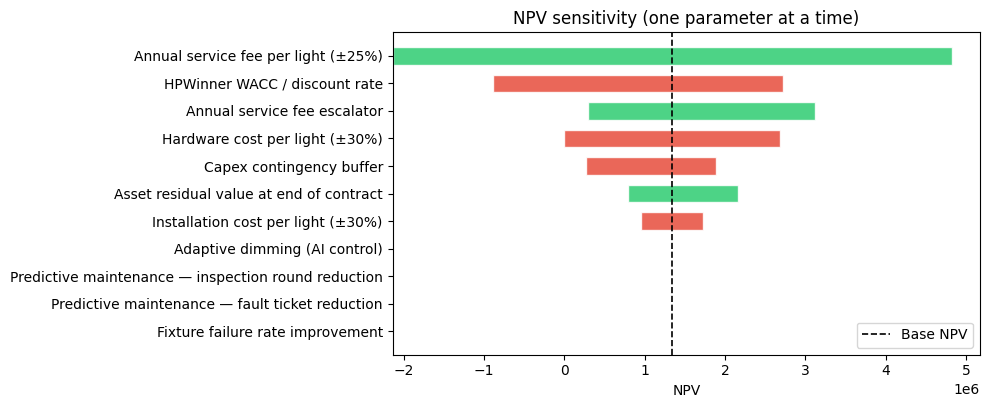

In [16]:
import matplotlib.pyplot as plt
import numpy as np

t = results.tornado
rows = t.rows
y = np.arange(len(rows))
left = np.array([min(r.npv_at_low, r.npv_at_high) for r in rows])
right = np.array([max(r.npv_at_low, r.npv_at_high) for r in rows])
width = right - left

fig, ax = plt.subplots(figsize=(10, max(4, 0.38 * len(rows))))
colors = ["#2ecc71" if r.direction == "positive" else "#e74c3c" for r in rows]
ax.barh(y, width, left=left, height=0.65, color=colors, alpha=0.85, edgecolor="white")
ax.axvline(t.base_npv, color="black", linestyle="--", linewidth=1.2, label="Base NPV")
ax.set_yticks(y, labels=[r.display_name for r in rows])
ax.invert_yaxis()
ax.set_xlabel("NPV")
ax.set_title("NPV sensitivity (one parameter at a time)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


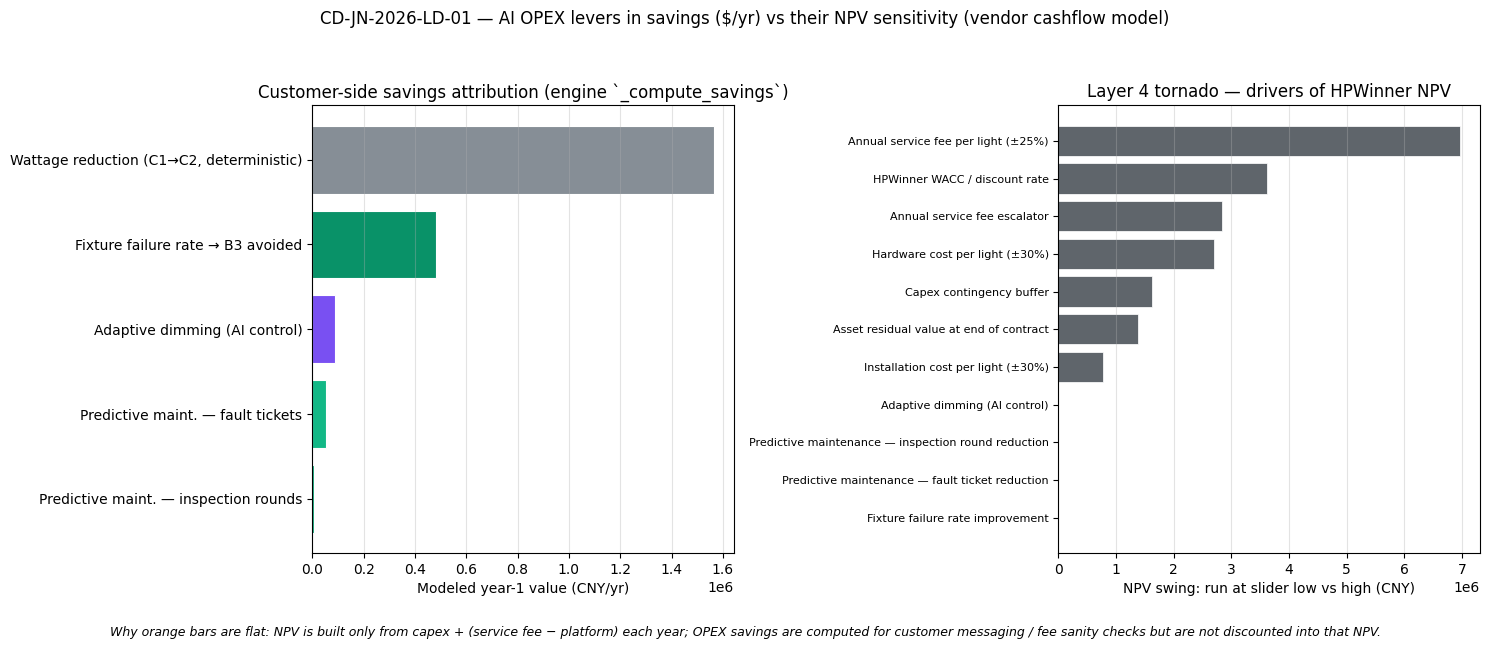

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from layer2 import load_savings
from layer4 import run_scenarios

# Full Layer 4 pack (same deal / product / params as `run_model` cell)
results = run_scenarios(
    deal,
    product,
    params,
    load_savings(),
    load_financial(),
    config_versions=config_versions(),
    n_simulations=300,
    mc_seed=42,
)
ccy = deal.currency
sav = results.point_estimate.annual_savings

# Left: Year-1 $ attribution (customer / “selling story” view)
story = [
    ("wattage_reduction", "Wattage reduction (C1→C2, deterministic)", "#868e96"),
    ("adaptive_dimming", "Adaptive dimming (AI control)", "#7950f2"),
    ("inspection_reduction", "Predictive maint. — inspection rounds", "#0ca678"),
    ("ticket_reduction", "Predictive maint. — fault tickets", "#12b886"),
    ("failure_rate_reduction", "Fixture failure rate → B3 avoided", "#099268"),
]
labs = [t[1] for t in story]
vals = np.array([getattr(sav, t[0]) for t in story])
cols = [t[2] for t in story]
order = np.argsort(vals)[::-1]
labs = [labs[i] for i in order]
vals = vals[order]
cols = [cols[i] for i in order]

# Right: Tornado NPV swings (HPWinner cashflow model)
rows = results.tornado.rows
AI_FIELDS = {
    "adaptive_dimming_pct",
    "inspection_reduction_pct",
    "ticket_reduction_pct",
    "failure_reduction_pct",
}
t_labs = [r.display_name for r in rows]
t_sw = np.array([r.npv_swing for r in rows])
t_cols = ["#fd7e14" if r.parameter in AI_FIELDS else "#495057" for r in rows]

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(15, 6.2))
ax_a.barh(labs, vals, color=cols, edgecolor="white", linewidth=0.8)
ax_a.set_xlabel(f"Modeled year-1 value ({ccy}/yr)")
ax_a.set_title("Customer-side savings attribution (engine `_compute_savings`)")
ax_a.invert_yaxis()
ax_a.grid(True, axis="x", alpha=0.35)

y = np.arange(len(rows))
ax_b.barh(y, t_sw, color=t_cols, alpha=0.88, edgecolor="white", linewidth=0.6)
ax_b.set_yticks(y, labels=t_labs, fontsize=8)
ax_b.set_xlabel(f"NPV swing: run at slider low vs high ({ccy})")
ax_b.set_title("Layer 4 tornado — drivers of HPWinner NPV")
ax_b.invert_yaxis()
ax_b.grid(True, axis="x", alpha=0.35)

fig.text(
    0.5,
    0.01,
    "Why orange bars are flat: NPV is built only from capex + (service fee − platform) each year; "
    "OPEX savings are computed for customer messaging / fee sanity checks but are not discounted into that NPV.",
    ha="center",
    fontsize=9,
    style="italic",
)
fig.suptitle(
    f"{deal.deal_id} — AI OPEX levers in savings ($/yr) vs their NPV sensitivity (vendor cashflow model)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()


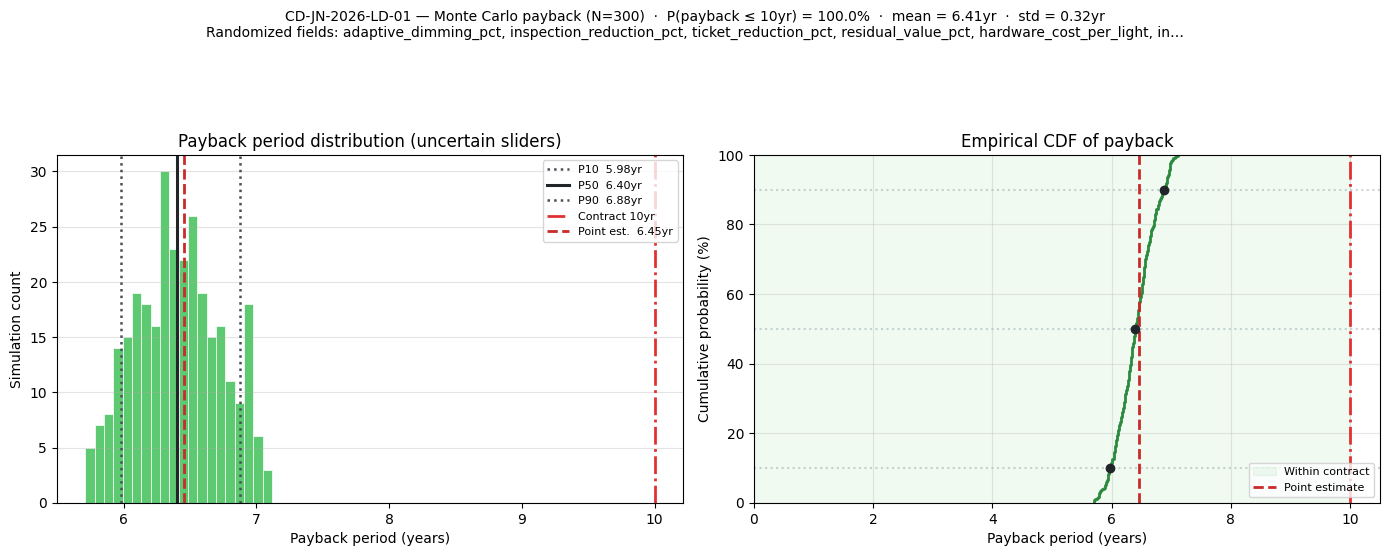

Payback band: P10 6.0yr / P50 6.4yr / P90 6.9yr
Never recovers (no payback in contract): 0.0%


In [19]:
# Monte Carlo effect on payback period — requires `results` from the `run_scenarios(...)` cell above
import matplotlib.pyplot as plt
import numpy as np
import importlib
import layer4.models
importlib.reload(layer4.models)
from layer4 import run_scenarios

mc = results.montecarlo
contract_yrs = params.contract_yrs

# Check if we have payback data
if not mc.payback_samples or len(mc.payback_samples) < mc.n_simulations * 0.5:
    print("Insufficient payback data. Re-run run_scenarios() with updated montecarlo.py to collect payback samples.")
else:
    samples = np.asarray(mc.payback_samples, dtype=float)
    base_payback = results.point_estimate.payback_years
    
    fig, (ax_h, ax_c) = plt.subplots(1, 2, figsize=(14, 5.2))
    
    # Histogram
    n_bins = min(45, max(20, mc.n_simulations // 20))
    ax_h.hist(samples, bins=n_bins, color="#40c057", edgecolor="white", linewidth=0.6, alpha=0.85)
    ax_h.axvline(mc.payback_p10, color="#495057", ls=":", lw=1.8, label=f"P10  {mc.payback_p10:.2f}yr")
    ax_h.axvline(mc.payback_p50, color="#212529", ls="-", lw=2.2, label=f"P50  {mc.payback_p50:.2f}yr")
    ax_h.axvline(mc.payback_p90, color="#495057", ls=":", lw=1.8, label=f"P90  {mc.payback_p90:.2f}yr")
    ax_h.axvline(contract_yrs, color="#e03131", ls="-.", lw=2.0, label=f"Contract {contract_yrs}yr")
    if base_payback is not None:
        ax_h.axvline(base_payback, color="#c92a2a", ls="--", lw=2.0, label=f"Point est.  {base_payback:.2f}yr")
    ax_h.set_xlabel("Payback period (years)")
    ax_h.set_ylabel("Simulation count")
    ax_h.set_title("Payback period distribution (uncertain sliders)")
    ax_h.legend(loc="upper right", fontsize=8)
    ax_h.grid(True, axis="y", alpha=0.35)
    
    # CDF
    xs = np.sort(samples)
    ys = np.arange(1, len(xs) + 1) / len(xs) * 100.0
    ax_c.plot(xs, ys, color="#2b8a3e", lw=2.0, drawstyle="steps-post")
    ax_c.axhline(10, color="#ced4da", ls=":", zorder=0)
    ax_c.axhline(50, color="#ced4da", ls=":", zorder=0)
    ax_c.axhline(90, color="#ced4da", ls=":", zorder=0)
    ax_c.axvline(contract_yrs, color="#e03131", ls="-.", lw=2.0, zorder=2)
    ax_c.fill_betweenx([0, 100], 0, contract_yrs, color="#40c057", alpha=0.08, label=f"Within contract")
    ax_c.scatter([mc.payback_p10, mc.payback_p50, mc.payback_p90], [10, 50, 90], color="#212529", s=36, zorder=3)
    if base_payback is not None:
        ax_c.axvline(base_payback, color="#c92a2a", ls="--", lw=2.0, label="Point estimate")
    ax_c.set_xlabel("Payback period (years)")
    ax_c.set_ylabel("Cumulative probability (%)")
    ax_c.set_title("Empirical CDF of payback")
    ax_c.set_ylim(0, 100)
    ax_c.set_xlim(left=0)
    ax_c.grid(True, alpha=0.3)
    ax_c.legend(loc="lower right", fontsize=8)
    
    vp = mc.varied_parameters
    vp_txt = ", ".join(vp) if vp else "(none)"
    if len(vp_txt) > 120:
        vp_txt = vp_txt[:117] + "…"
    
    prob_recover = mc.prob_payback_in_contract or 0.0
    never_recover = 1.0 - (len(samples) / mc.n_simulations)
    
    fig.suptitle(
        f"{deal.deal_id} — Monte Carlo payback (N={mc.n_simulations})  ·  "
        f"P(payback ≤ {contract_yrs}yr) = {prob_recover:.1%}  ·  mean = {mc.payback_mean:.2f}yr  ·  std = {mc.payback_std:.2f}yr\n"
        f"Randomized fields: {vp_txt}",
        fontsize=10,
        y=1.06,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    
    print("Payback band:", mc.payback_range_label)
    print(f"Never recovers (no payback in contract): {never_recover:.1%}")

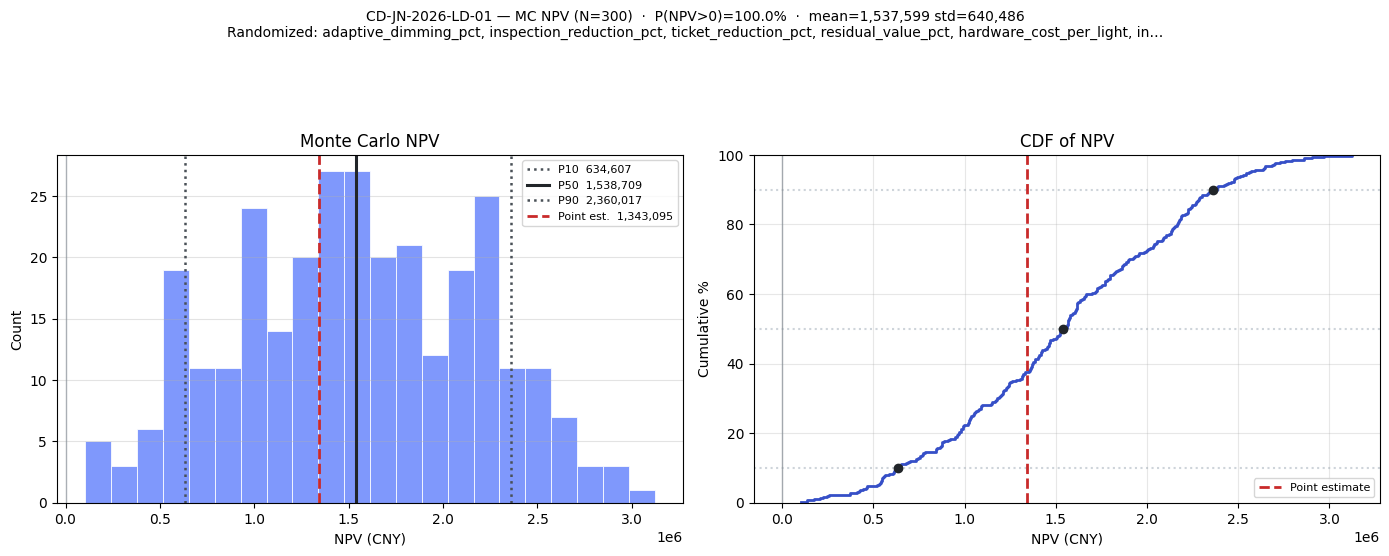

NPV band: P10 634,607 / P50 1.5M / P90 2.4M


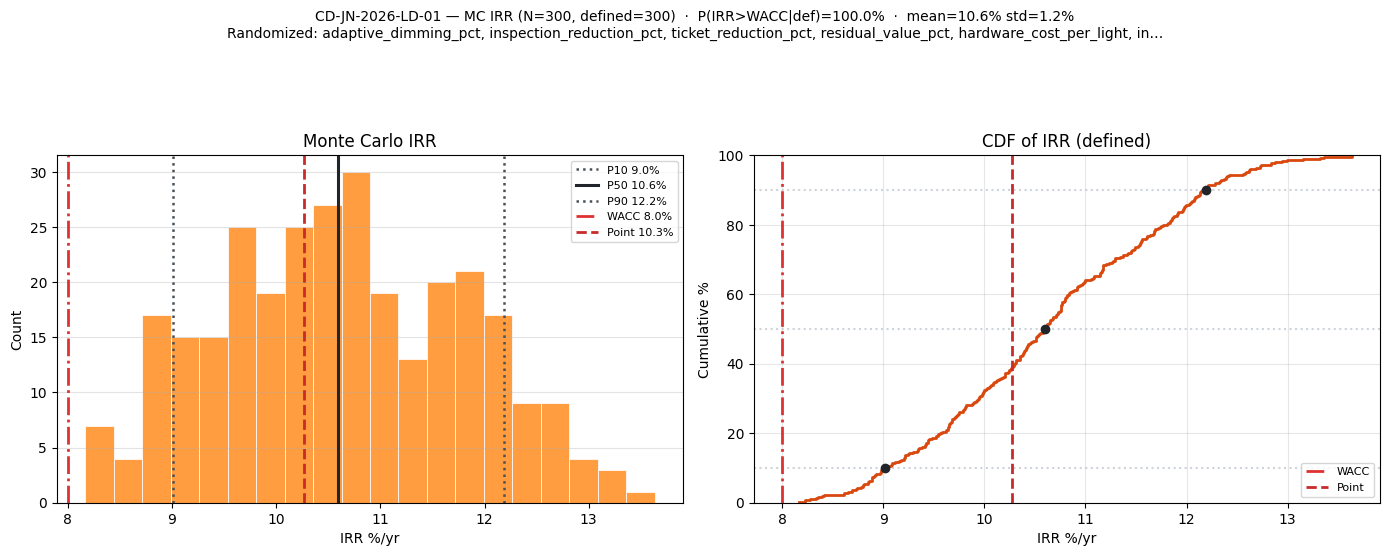

IRR band: P10 9.0% / P50 10.6% / P90 12.2%
IRR band: P10 9.0% / P50 10.6% / P90 12.2%
Sims with no IRR: 0.0%


In [20]:
import matplotlib.pyplot as plt
import numpy as np

mc = results.montecarlo
ccy = deal.currency
n_sim = mc.n_simulations

# --- NPV ---
npv_s = np.asarray(mc.npv_samples, dtype=float)
pt_npv = float(results.point_estimate.npv)
_vp = getattr(mc, "varied_parameters", None) or []
vp_txt = ", ".join(_vp) if _vp else "(none)"
if len(vp_txt) > 120:
    vp_txt = vp_txt[:117] + "…"

if npv_s.size:
    fig, (ax_h, ax_c) = plt.subplots(1, 2, figsize=(14, 5.2))
    ax_h.hist(npv_s, bins=min(55, max(22, n_sim // 15)), color="#748ffc", edgecolor="white", linewidth=0.6, alpha=0.92)
    ax_h.axvline(mc.npv_p10, color="#495057", ls=":", lw=1.8, label=f"P10  {mc.npv_p10:,.0f}")
    ax_h.axvline(mc.npv_p50, color="#212529", ls="-", lw=2.2, label=f"P50  {mc.npv_p50:,.0f}")
    ax_h.axvline(mc.npv_p90, color="#495057", ls=":", lw=1.8, label=f"P90  {mc.npv_p90:,.0f}")
    ax_h.axvline(pt_npv, color="#c92a2a", ls="--", lw=2.0, label=f"Point est.  {pt_npv:,.0f}")
    ax_h.axvline(0, color="#868e96", ls="-", lw=1.0, alpha=0.7)
    ax_h.set_xlabel(f"NPV ({ccy})"); ax_h.set_ylabel("Count"); ax_h.set_title("Monte Carlo NPV")
    ax_h.legend(loc="upper right", fontsize=8); ax_h.grid(True, axis="y", alpha=0.35)
    xs = np.sort(npv_s); ys = np.arange(1, len(xs) + 1) / len(xs) * 100.0
    ax_c.plot(xs, ys, color="#364fc7", lw=2.0, drawstyle="steps-post")
    for q in (10, 50, 90): ax_c.axhline(q, color="#ced4da", ls=":", zorder=0)
    ax_c.axvline(0, color="#868e96", lw=1.0, alpha=0.7)
    ax_c.scatter([mc.npv_p10, mc.npv_p50, mc.npv_p90], [10, 50, 90], color="#212529", s=36, zorder=3)
    ax_c.axvline(pt_npv, color="#c92a2a", ls="--", lw=2.0, label="Point estimate")
    ax_c.set_xlabel(f"NPV ({ccy})"); ax_c.set_ylabel("Cumulative %"); ax_c.set_title("CDF of NPV")
    ax_c.set_ylim(0, 100); ax_c.grid(True, alpha=0.3); ax_c.legend(loc="lower right", fontsize=8)
    fig.suptitle(
        f"{deal.deal_id} — MC NPV (N={n_sim})  ·  P(NPV>0)={mc.prob_positive_npv:.1%}  ·  "
        f"mean={mc.npv_mean:,.0f} std={mc.npv_std:,.0f}\nRandomized: {vp_txt}",
        fontsize=10, y=1.06,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()
    print("NPV band:", mc.npv_range_label)

# --- IRR (defined draws only) ---
wacc = float(params.hpwinner_wacc_pct)
raw = getattr(mc, "irr_samples", None)
if raw is None:
    print("No `irr_samples` — update layer4 + re-run run_scenarios, or restart kernel.")
else:
    irr = np.asarray(raw, dtype=float)
    ok = irr[np.isfinite(irr)]
    need = max(1, int(n_sim * 0.5))
    if ok.size < need:
        print(f"Too few IRR values ({ok.size}/{n_sim}).")
    else:
        pe = results.point_estimate
        pt_irr = pe.irr * 100.0 if pe.irr is not None else None
        p10, p50, p90 = mc.irr_p10, mc.irr_p50, mc.irr_p90
        fig, (ax_h, ax_c) = plt.subplots(1, 2, figsize=(14, 5.2))
        ax_h.hist(ok, bins=min(50, max(20, ok.size // 15)), color="#ff922b", edgecolor="white", linewidth=0.6, alpha=0.9)
        if p10 is not None: ax_h.axvline(p10, color="#495057", ls=":", lw=1.8, label=f"P10 {p10:.1f}%")
        if p50 is not None: ax_h.axvline(p50, color="#212529", ls="-", lw=2.2, label=f"P50 {p50:.1f}%")
        if p90 is not None: ax_h.axvline(p90, color="#495057", ls=":", lw=1.8, label=f"P90 {p90:.1f}%")
        ax_h.axvline(wacc, color="#e03131", ls="-.", lw=2.0, label=f"WACC {wacc:.1f}%")
        if pt_irr is not None: ax_h.axvline(pt_irr, color="#c92a2a", ls="--", lw=2.0, label=f"Point {pt_irr:.1f}%")
        ax_h.set_xlabel("IRR %/yr"); ax_h.set_ylabel("Count"); ax_h.set_title("Monte Carlo IRR")
        ax_h.legend(loc="upper right", fontsize=8); ax_h.grid(True, axis="y", alpha=0.35)
        xs = np.sort(ok); ys = np.arange(1, len(xs) + 1) / len(xs) * 100.0
        ax_c.plot(xs, ys, color="#d9480f", lw=2.0, drawstyle="steps-post")
        for q in (10, 50, 90): ax_c.axhline(q, color="#ced4da", ls=":", zorder=0)
        ax_c.axvline(wacc, color="#e03131", ls="-.", lw=2.0, label="WACC")
        if p10 is not None and p50 is not None and p90 is not None:
            ax_c.scatter([p10, p50, p90], [10, 50, 90], color="#212529", s=36, zorder=3)
        if pt_irr is not None: ax_c.axvline(pt_irr, color="#c92a2a", ls="--", lw=2.0, label="Point")
        ax_c.set_xlabel("IRR %/yr"); ax_c.set_ylabel("Cumulative %"); ax_c.set_title("CDF of IRR (defined)")
        ax_c.set_ylim(0, 100); ax_c.grid(True, alpha=0.3); ax_c.legend(loc="lower right", fontsize=8)
        above = float(np.mean(ok > wacc))
        miss = 1.0 - ok.size / n_sim
        m, s = mc.irr_mean, mc.irr_std
        fig.suptitle(
            f"{deal.deal_id} — MC IRR (N={n_sim}, defined={ok.size})  ·  P(IRR>WACC|def)={above:.1%}  ·  "
            f"mean={m:.1f}% std={s:.1f}%\nRandomized: {vp_txt}",
            fontsize=10, y=1.06,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()
        print("IRR band:", getattr(mc, "irr_range_label", lambda: "N/A")() if False else getattr(mc, "irr_range_label", "N/A"))
        try:
            print("IRR band:", mc.irr_range_label)
        except AttributeError:
            pass
        print(f"Sims with no IRR: {miss:.1%}")